## "Há evidências de que filmes de ação lançados a partir de 2005 apresentam desempenho comercial inferior aos lançados anteriormente?"

A partir desse questionamento, podemos olhar mais especificamente para três dados(Colunas) em especifico: 

**Year**(O ano em que foi lançado o filme) <br> <br>
**World Wide Sales (in $)** (Que é o montante total que o filme lucrou mundialmente). <br> <br>
**Genre** (Que é o genero do filme em questão)

## Hipótese

**Conforme o passar dos anos, os filmes de ação diminuiram com o lucro mundial. Assim, indicando uma proporção invertidade do lucro em relação ao ano de lançamento**

Primeiro precisamos filtrar os dados para pegar apenas os dados de filmes de ação e para valores que fazem sentido em ano(> 1900) e venda(> 0):

In [10]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)
df.head()


C:\Users\gabri\AppData\Local\Temp\ipykernel_30548\2974614052.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)


,Unnamed: 0,Title,Movie Info,Year,Distributor,Budget (in $),Domestic Opening (in $),Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Release Date,Genre,Running Time,License
0,0,Avatar,A paraplegic Marine dispatched to the moon Pan...,2009,Twentieth Century Fox,237000000,77025481,785221649,2138484377,2923706026,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
1,1,Avengers: Endgame,After the devastating events of Avengers: Infi...,2019,Walt Disney Studios Motion Pictures,356000000,357115007,858373000,1941066100,2799439100,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,2,Avatar: The Way of Water,Jake Sully lives with his newfound family form...,2022,20th Century Studios,December 14 2022 (EMEA APAC),134100226,684075767,1636174514,2320250281,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
3,3,Titanic,A seventeen-year-old aristocrat falls in love ...,1997,Paramount Pictures,200000000,28638131,674292608,1590450697,2264743305,19-Dec-97,"['Drama', 'Romance']",3 hr 14 min,PG-13
4,4,Star Wars: Episode VII - The Force Awakens,"As a new threat to the galaxy rises, Rey, a de...",2015,Walt Disney Studios Motion Pictures,245000000,247966675,936662225,1134647993,2071310218,16-Dec-15,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13


Vamos entender a estrutura geral:

In [25]:
print(df.info())
print('Quantidade de linhas duplicadas:', df.duplicated().sum())
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Unnamed: 0                  1000 non-null   int64
 1   Title                       1000 non-null   str  
 2   Movie Info                  1000 non-null   str  
 3   Year                        1000 non-null   int64
 4   Distributor                 999 non-null    str  
 5   Budget (in $)               1000 non-null   str  
 6   Domestic Opening (in $)     1000 non-null   str  
 7   Domestic Sales (in $)       1000 non-null   int64
 8   International Sales (in $)  1000 non-null   int64
 9   World Wide Sales (in $)     1000 non-null   int64
 10  Release Date                1000 non-null   str  
 11  Genre                       1000 non-null   str  
 12  Running Time                1000 non-null   str  
 13  License                     943 non-null    str  
dtypes: int64(5), str(9)


,Unnamed: 0,Title,Movie Info,Year,Distributor,Budget (in $),Domestic Opening (in $),Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Release Date,Genre,Running Time,License
count,1000.000000,1000,1000,1000.000000,999,1000,1000,1.000000e+03,1.000000e+03,1.000000e+03,1000,1000,1000,943
unique,NaN,988,999,NaN,71,361,997,NaN,NaN,NaN,713,275,100,4
top,NaN,The Lion King,A kind-hearted street urchin and a power-hungr...,NaN,Warner Bros.,150000000,2 hr 2 min,NaN,NaN,NaN,28-Jun-07,"['Action', 'Adventure', 'Sci-Fi']",1 hr 46 min,PG-13
freq,NaN,2,2,NaN,166,44,2,NaN,NaN,NaN,5,70,27,486
mean,499.500000,NaN,NaN,2008.181000,NaN,NaN,NaN,1.646405e+08,2.640890e+08,4.228430e+08,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,10.585854,NaN,NaN,NaN,1.197541e+08,2.133847e+08,3.054844e+08,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,1937.000000,NaN,NaN,NaN,6.752000e+03,2.450000e+07,1.799689e+08,NaN,NaN,NaN,NaN
25%,249.750000,NaN,NaN,2002.000000,NaN,NaN,NaN,9.572506e+07,1.321190e+08,2.272899e+08,NaN,NaN,NaN,NaN
50%,499.500000,NaN,NaN,2010.000000,NaN,NaN,NaN,1.349169e+08,1.941077e+08,3.197148e+08,NaN,NaN,NaN,NaN
75%,749.250000,NaN,NaN,2016.000000,NaN,NaN,NaN,1.983993e+08,3.188993e+08,4.852363e+08,NaN,NaN,NaN,NaN


#### Agora vamos especificar o gênero ação:

In [19]:
df_action = df[
    df["Genre"].apply(lambda generos: "Action" in generos)
    & (df["Year"] >= 1900)
    & (df["World Wide Sales (in $)"] >= 0)
].copy()

df_action[["Title", "Year", "Genre", "World Wide Sales (in $)"]]

,Title,Year,Genre,World Wide Sales (in $)
0,Avatar,2009,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2923706026
1,Avengers: Endgame,2019,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",2799439100
2,Avatar: The Way of Water,2022,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",2320250281
4,Star Wars: Episode VII - The Force Awakens,2015,"['Action', 'Adventure', 'Sci-Fi']",2071310218
5,Avengers: Infinity War,2018,"['Action', 'Adventure', 'Sci-Fi']",2052415039
...,...,...,...,...
991,Hot Shots!,1991,"['Action', 'Comedy']",181096164
993,Kill Bill: Vol. 1,2003,"['Action', 'Crime', 'Thriller']",180906076
994,The Scorpion King,2002,"['Action', 'Adventure', 'Fantasy']",180630907
998,Deja Vu,2006,"['Action', 'Crime', 'Sci-Fi', 'Thriller']",180557550


## Pré-processamento de dados

Observando os campos que iremos analisar, podemos ver que não há nenhum campo nulo ou duplicado, e os dados estão coerentes tanto no tipo como na consistência.<br><br>
Portanto, tendo em vista que estamos lidando com escalas de valores distantes, para a melhor visualização em graficos do problema, o ideal é fazermos uma normalização dos dados. Mas para isso, ou qualquer outra operação que fizermos, precisamos descobrir como são os dados que estamos lidando. Ele tem muitos outliers? Há valores fora do padrão? Em negativo?

Logo, outrora filtrei os dados e agora para isso, vou utilizar a media e mediana juntamente com uma visualização grafica de datagrama para tentar encontrar o maximo de outliers na relação entre o lucro mundial e o ano, juntamente com os quartis e Amplitude, desvio padrão e variância:

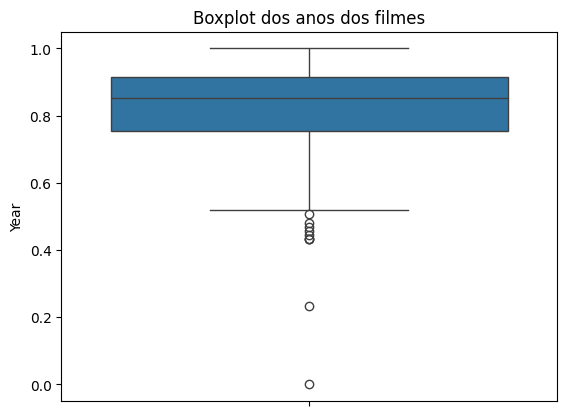

Mediana dos anos: 2011.0
Média dos anos: 2008.6948818897638
Q1: 2003.0
Q2: 2011.0
Q3: 2016.0
Q4: 2023.0
Amplitude: 81 anos
Variância: 107.48660097221577
Desvio padrão: 10.367574498030663



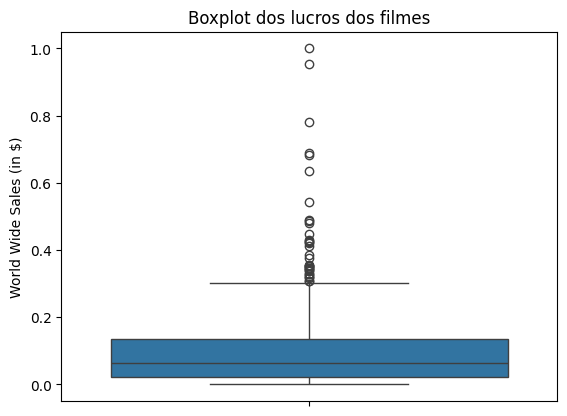

Mediana das vendas mundiais: 351015776.0
Média das vendas mundiais: 465332656.242126
Q1: 240563205.75
Q2: 351015776.0
Q3: 552907125.25
Q4: 2923706026.0
Amplitude: 2743737153
Variância: 1.2017015843694398e+17
Desvio padrão: 346655677.0585821


In [13]:
df_normalizado = df_action.copy()

df_normalizado["Year"] = (
    (df_action["Year"] - df_action["Year"].min()) /
    (df_action["Year"].max() - df_action["Year"].min())
)

df_normalizado["World Wide Sales (in $)"] = (
    (df_action["World Wide Sales (in $)"] - df_action["World Wide Sales (in $)"].min()) /
    (df_action["World Wide Sales (in $)"].max() - df_action["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_action['Year'].median()}\nMédia dos anos: {df_action['Year'].mean()}")
print(f"Q1: {df_action['Year'].quantile(.25)}\nQ2: {df_action['Year'].quantile(.50)}\nQ3: {df_action['Year'].quantile(.75)}\nQ4: {df_action['Year'].quantile(1.00)}")
print(f"Amplitude: {df_action['Year'].max() - df_action['Year'].min()} anos")
print(f"Variância: {df_action['Year'].var()}")
print(f"Desvio padrão: {df_action['Year'].std()}")
print()

sns.boxplot(y=df_normalizado['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_action['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_action['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_action['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_action['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_action['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_action['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_action['World Wide Sales (in $)'].max() - df_action['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_action['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_action['World Wide Sales (in $)'].std()}")

## Análise parcial:

### Ano
Podemos observar a partir dos graficos e das informações que a maioria dos filmes está concentrado nos anos mais atuais com poucos filmes bem mais antigos. Podemos concluir isso observando os quartis e o intervalo entre eles. a maioria dos filmes está entre 2002 a 2023. O que ajuda na compreensão desses dados também, é a amplitude muito alta (86 anos) e mesmo assim, uma variância (10 anos) pequena em relação a amplitude, sugerindo uma grande concentração desses dados nos anos mais recente.<br> <br>
### Lucro
Juntamente com isso, pode-se observar que os maiores lucros são alguns outliers mas a maioria se concentra bem abaixo da media. O que sugere que há bilheterias muito altas puxando o valor para cima (outliers). Outro dado que reforça isso é o desvio padrão muito alto, mostrando uma grande variação nos valores de bilheteria.

### Ao analisar de maneira Conjunta os dados, podemos chegar a conclusão que:
A análise inicial dos filmes de ação mostrou que a arrecadação mundial apresenta grande dispersão e forte presença de outliers, indicando uma distribuição assimétrica. A diferença entre média e mediana reforça que poucos filmes concentram arrecadações muito elevadas, o que distorce a média do conjunto. Dessa forma, para responder à pergunta de pesquisa com mais precisão, a próxima etapa consiste em comparar separadamente os filmes lançados antes de 2005 com aqueles lançados a partir de 2005.

#### Para uma maior precisão, após aplicar esses filtros, precisamos dividir os dados em dois quadrantes:<br><br>

##### Pré 2005<br><br>
##### Pós 2005<br><br>

Essa separação permite comparar diretamente o desempenho comercial entre os dois períodos.

In [26]:
df_action_pre = df_action[
    df_action['Year'] < 2005
    ]

df_action_pos = df_action[
    df_action['Year'] >= 2005
    ]

# Pré-2005

Filmes de ação antes de 2005: 152


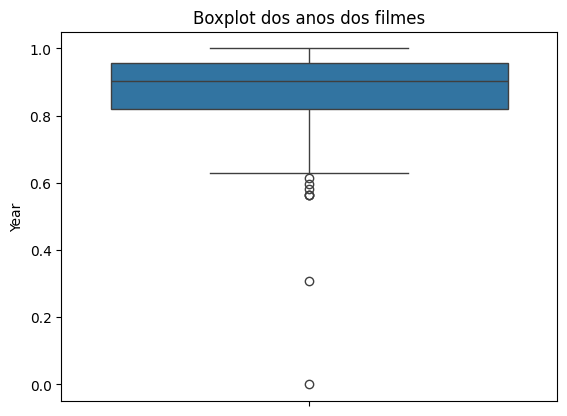

Mediana dos anos: 1998.0
Média dos anos: 1995.8026315789473
Q1: 1992.75
Q2: 1998.0
Q3: 2001.25
Q4: 2004.0
Amplitude: 62 anos
Variância: 70.53032415475775
Desvio padrão: 8.398233394872861



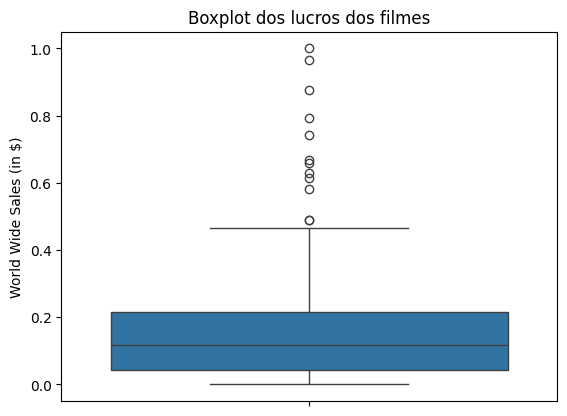

Mediana das vendas mundiais: 293587398.5
Média das vendas mundiais: 348617211.30921054
Q1: 222569299.25
Q2: 293587398.5
Q3: 390067955.25
Q4: 1147633833.0
Amplitude: 967002926
Variância: 3.510390408925029e+16
Desvio padrão: 187360358.90564016


In [27]:
df_normalizado_pre = df_action_pre.copy()
print("Filmes de ação antes de 2005:", len(df_action_pre))

df_normalizado_pre["Year"] = (
    (df_action_pre["Year"] - df_action_pre["Year"].min()) /
    (df_action_pre["Year"].max() - df_action_pre["Year"].min())
)

df_normalizado_pre["World Wide Sales (in $)"] = (
    (df_action_pre["World Wide Sales (in $)"] - df_action_pre["World Wide Sales (in $)"].min()) /
    (df_action_pre["World Wide Sales (in $)"].max() - df_action_pre["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado_pre['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_action_pre['Year'].median()}\nMédia dos anos: {df_action_pre['Year'].mean()}")
print(f"Q1: {df_action_pre['Year'].quantile(.25)}\nQ2: {df_action_pre['Year'].quantile(.50)}\nQ3: {df_action_pre['Year'].quantile(.75)}\nQ4: {df_action_pre['Year'].quantile(1.00)}")
print(f"Amplitude: {df_action_pre['Year'].max() - df_action_pre['Year'].min()} anos")
print(f"Variância: {df_action_pre['Year'].var()}")
print(f"Desvio padrão: {df_action_pre['Year'].std()}")
print()

sns.boxplot(y=df_normalizado_pre['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_action_pre['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_action_pre['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_action_pre['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_action_pre['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_action_pre['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_action_pre['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_action_pre['World Wide Sales (in $)'].max() - df_action_pre['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_action_pre['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_action_pre['World Wide Sales (in $)'].std()}")

# Pós-2005

Filmes de ação antes de 2005: 356


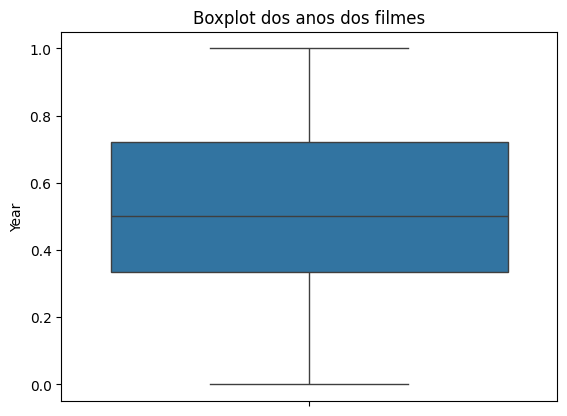

Mediana dos anos: 2014.0
Média dos anos: 2014.1994382022472
Q1: 2011.0
Q2: 2014.0
Q3: 2018.0
Q4: 2023.0
Amplitude: 18 anos
Variância: 21.957295458142113
Desvio padrão: 4.685861229074343



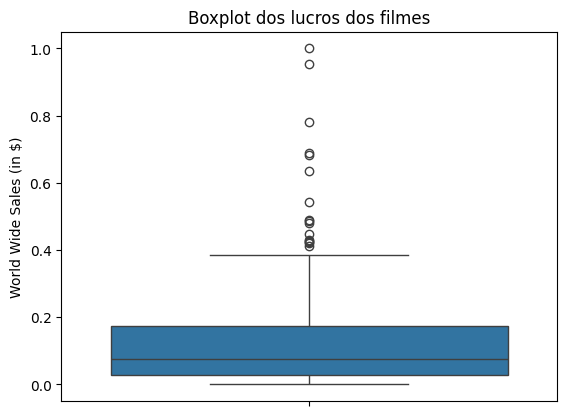

Mediana das vendas mundiais: 386140292.0
Média das vendas mundiais: 515166217.0
Q1: 253329813.75
Q2: 386140292.0
Q3: 657884011.25
Q4: 2923706026.0
Amplitude: 2743737153
Variância: 1.48368667414363e+17
Desvio padrão: 385186535.86848414


In [28]:
df_normalizado_pos = df_action_pos.copy()
print("Filmes de ação antes de 2005:", len(df_action_pos))

df_normalizado_pos["Year"] = (
    (df_action_pos["Year"] - df_action_pos["Year"].min()) /
    (df_action_pos["Year"].max() - df_action_pos["Year"].min())
)

df_normalizado_pos["World Wide Sales (in $)"] = (
    (df_action_pos["World Wide Sales (in $)"] - df_action_pos["World Wide Sales (in $)"].min()) /
    (df_action_pos["World Wide Sales (in $)"].max() - df_action_pos["World Wide Sales (in $)"].min())
)
sns.boxplot(y=df_normalizado_pos['Year'])
plt.title("Boxplot dos anos dos filmes")
plt.show()

print(f"Mediana dos anos: {df_action_pos['Year'].median()}\nMédia dos anos: {df_action_pos['Year'].mean()}")
print(f"Q1: {df_action_pos['Year'].quantile(.25)}\nQ2: {df_action_pos['Year'].quantile(.50)}\nQ3: {df_action_pos['Year'].quantile(.75)}\nQ4: {df_action_pos['Year'].quantile(1.00)}")
print(f"Amplitude: {df_action_pos['Year'].max() - df_action_pos['Year'].min()} anos")
print(f"Variância: {df_action_pos['Year'].var()}")
print(f"Desvio padrão: {df_action_pos['Year'].std()}")
print()

sns.boxplot(y=df_normalizado_pos['World Wide Sales (in $)'])
plt.title("Boxplot dos lucros dos filmes")
plt.show()

print(
    f"Mediana das vendas mundiais: {df_action_pos['World Wide Sales (in $)'].median()}\n"
    f"Média das vendas mundiais: {df_action_pos['World Wide Sales (in $)'].mean()}"
)
print(
    f"Q1: {df_action_pos['World Wide Sales (in $)'].quantile(0.25)}\n"
    f"Q2: {df_action_pos['World Wide Sales (in $)'].quantile(0.50)}\n"
    f"Q3: {df_action_pos['World Wide Sales (in $)'].quantile(0.75)}\n"
    f"Q4: {df_action_pos['World Wide Sales (in $)'].quantile(1.00)}"
)
print(f"Amplitude: {df_action_pos['World Wide Sales (in $)'].max() - df_action_pos['World Wide Sales (in $)'].min()}")
print(f"Variância: {df_action_pos['World Wide Sales (in $)'].var()}")
print(f"Desvio padrão: {df_action_pos['World Wide Sales (in $)'].std()}")

Vamos usar também a correlação de Spearman para procurar uma proporção entre as medidas. Usaremos Sperman ao inves de Pearson devido a grande quantidade de outliers.

In [29]:
coef_spearman, p_spearman = spearmanr(df_action["Year"], df_action["World Wide Sales (in $)"])
print("Spearman:", coef_spearman)
print("p-valor:", p_spearman)

Spearman: 0.23168924027617951
p-valor: 1.2835867751264987e-07


## Conclusão
Após o pré-processamento e a separação dos filmes de ação em dois períodos, antes de 2005 e a partir de 2005, observou-se que os filmes mais recentes apresentam desempenho comercial superior.<br><br> A mediana das arrecadações mundiais dos filmes lançados a partir de 2005 foi de aproximadamente 386 milhões, enquanto a dos filmes anteriores a 2005 foi de aproximadamente 294 milhões. A média também foi maior no período mais recente, assim como os quartis, indicando que essa diferença não está restrita apenas a casos isolados.<br> O boxplot comparativo reforça essa interpretação ao mostrar distribuição de arrecadações mais elevada para os filmes lançados a partir de 2005. Além disso, a correlação de Spearman positiva, embora fraca, sugere uma tendência de crescimento da arrecadação ao longo do tempo. <br><br>Dessa forma, não há evidências de que filmes de ação lançados a partir de 2005 apresentem desempenho comercial inferior aos lançados anteriormente.

#### Vale salientar também, que esse estudo **não** leva em conta dados como inflação ao decorrer dos ano, desvalorização da moeda e outras variáveis. Apenas, puramente, os dados fornecidos pelo dataframe.

A seguir, graficos que facilitam a visão desses dados:

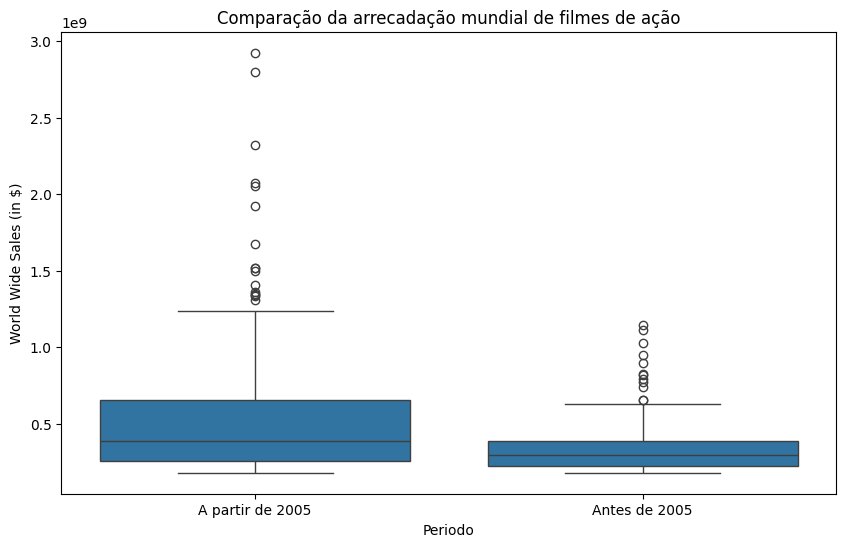

In [ ]:
df_action["Periodo"] = df_action["Year"].apply(lambda x: "Antes de 2005" if x < 2005 else "A partir de 2005")

plt.figure(figsize=(10,6))
sns.boxplot(data=df_action, x="Periodo", y="World Wide Sales (in $)")
plt.title("Comparação da arrecadação mundial de filmes de ação")
plt.ylabel("World Wide Sales (in $)")
plt.show()

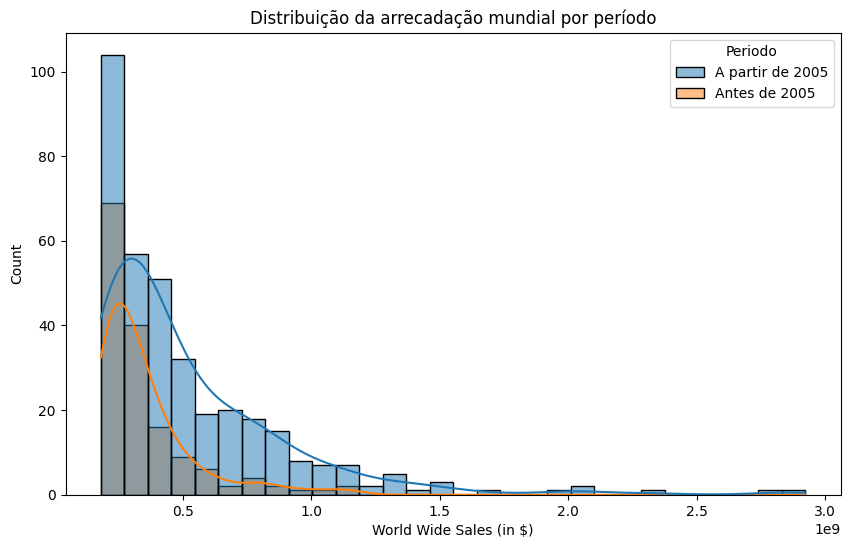

In [32]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_action, x="World Wide Sales (in $)", hue="Periodo", kde=True, bins=30)
plt.title("Distribuição da arrecadação mundial por período")
plt.show()